In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'CF'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'CF',
 'contract_multiplier': 5,
 'price_tick': 5,
 'margin_rate': 0.07,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'czce',
 'name': '棉花'}

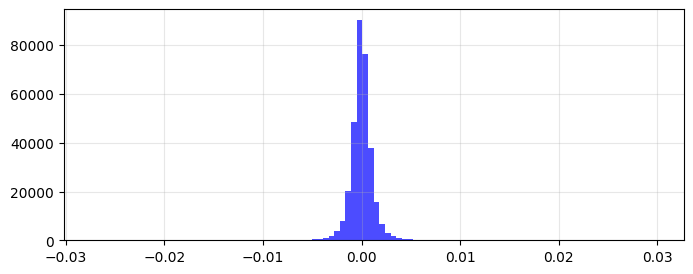

2025-07-01_CF_5


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['FAC_Depth_Reversal_downmean', 'FAC_Depth_Reversal_upmean', 'pred_ret']
特征分布性过滤：
筛选之前因子数量：1885， 筛选之后因子数量：1788

特征重要性过滤： 300 200 	待筛因子个数 1788
无向因子有效个数： 970 有向因子有效个数： 868
  选择有向特征 204 个，重要性范围: 985.00 - 30.00
  选择无向特征 141 个，重要性范围: 1360.00 - 44.00

单因子sharpe过滤： 0.5 sp范围-7.6019 ~ 7.623   待筛因子个数 345

特征相关性性过滤： 300     待筛因子个数 282
  选择特征 216 个, 特征最大相关性0.8972955225995323

已挑选日频开盘因子数量： 3 ['day_first3power', 'day_first10rev', 'day_jump']

排除指定因子后，剩余特征 215 个


(147, 0, 45, 23)

正在从 /mnt/Data/writable/liaoyuyang/factor/CF/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (318127, 1889)
训练集时间范围: 2021-02-01 09:11:00 至 2025-06-30 22:49:00
[200]	valid_0's rmse: 0.995924
[400]	valid_0's rmse: 0.996113
[600]	valid_0's rmse: 0.996355


<Figure size 1000x600 with 0 Axes>

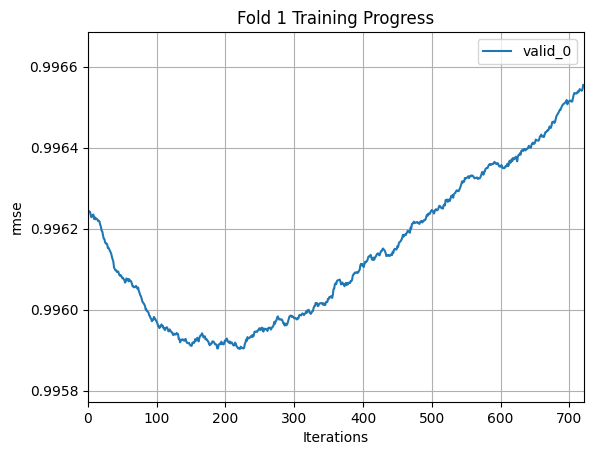

{'train_rmse': np.float64(0.9965973354548551), 'val_rmse': np.float64(0.9996799524759931), 'best_iteration': 221}
test_corr: -0.0003
[200]	valid_0's rmse: 0.995964
[400]	valid_0's rmse: 0.996104
[600]	valid_0's rmse: 0.996381


<Figure size 1000x600 with 0 Axes>

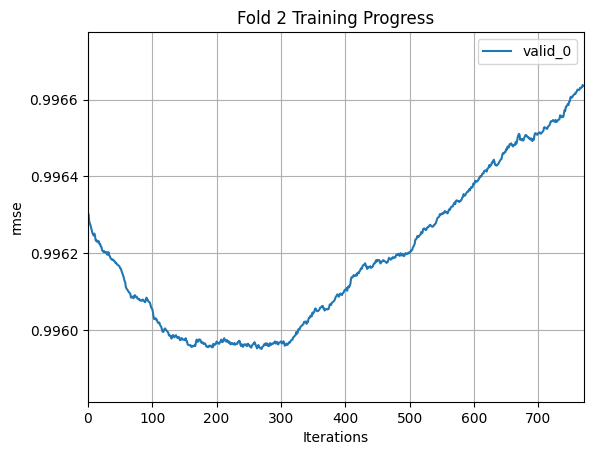

{'train_rmse': np.float64(0.9966113086828998), 'val_rmse': np.float64(0.9997290307361758), 'best_iteration': 271}
test_corr: 0.0040
[200]	valid_0's rmse: 0.995985
[400]	valid_0's rmse: 0.995856
[600]	valid_0's rmse: 0.995846
[800]	valid_0's rmse: 0.995891


<Figure size 1000x600 with 0 Axes>

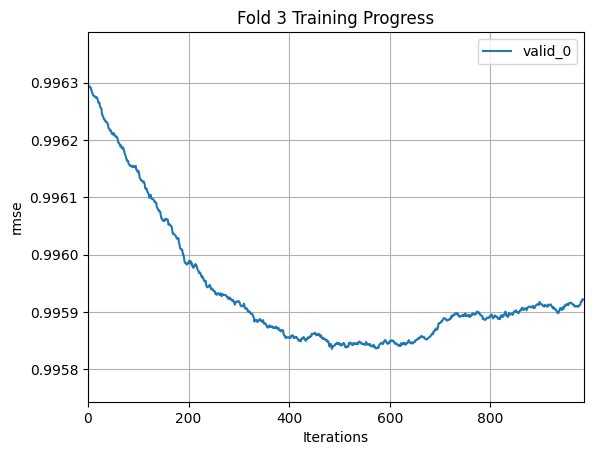

{'train_rmse': np.float64(0.993081652396027), 'val_rmse': np.float64(0.9996047333622345), 'best_iteration': 486}
test_corr: 0.0132
[200]	valid_0's rmse: 0.996311
[400]	valid_0's rmse: 0.996304
[600]	valid_0's rmse: 0.996322
[800]	valid_0's rmse: 0.996378


<Figure size 1000x600 with 0 Axes>

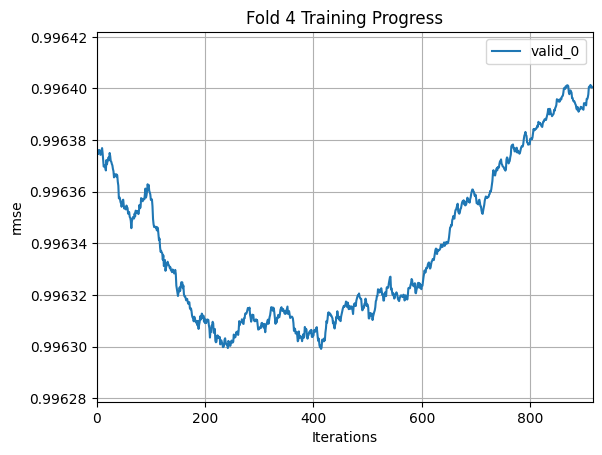

{'train_rmse': np.float64(0.9939591878542839), 'val_rmse': np.float64(1.0000751737219569), 'best_iteration': 415}
test_corr: -0.0156
[200]	valid_0's rmse: 0.996315
[400]	valid_0's rmse: 0.996359


<Figure size 1000x600 with 0 Axes>

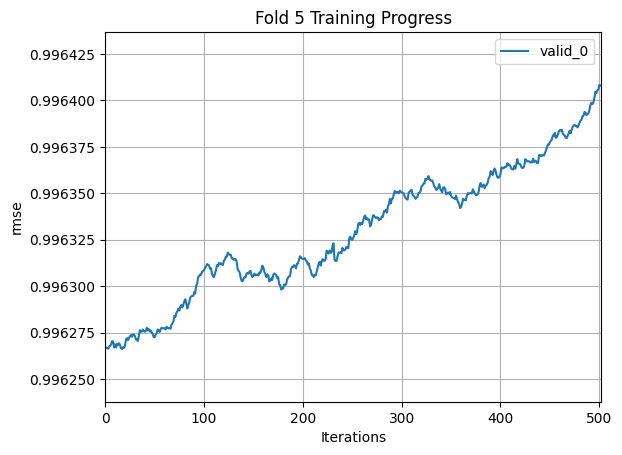

{'train_rmse': np.float64(0.9999488039958512), 'val_rmse': np.float64(1.0000460723724205), 'best_iteration': 2}
test_corr: 0.0036


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/CF_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-01 09:01:00,CF105,14920.0,14950.0,14915.0,14915.0,14925.777311,14924.677823,978.0,73006475.0,...,5.651261,437,2021-02-01,14941.25,14938.636364,14936.250000,14924.439252,-0.001435,0.000555,0.001043
1,2021-02-01 09:02:00,CF105,14920.0,14920.0,14905.0,14905.0,14913.506494,14913.455735,514.0,38325275.0,...,5.735931,369,2021-02-01,14919.00,14916.477273,14914.342105,14913.067633,0.001200,0.000433,0.003018
2,2021-02-01 09:03:00,CF105,14905.0,14910.0,14880.0,14900.0,14892.918455,14892.938225,465.0,34630350.0,...,5.815451,384,2021-02-01,14904.50,14901.785714,14896.710526,14891.674641,0.000916,0.000271,0.002294
3,2021-02-01 09:04:00,CF105,14900.0,14920.0,14895.0,14915.0,14908.679245,14908.890934,181.0,13493200.0,...,5.117925,320,2021-02-01,14899.25,14901.538462,14902.714286,14909.547872,0.000024,-0.000718,0.003167
4,2021-02-01 09:05:00,CF105,14915.0,14935.0,14915.0,14930.0,14922.651163,14922.077461,205.0,15293225.0,...,5.069767,344,2021-02-01,14915.25,14917.948718,14918.974359,14923.205128,-0.000149,-0.000460,0.003324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418896,2026-03-09 14:56:00,CF605,15325.0,15325.0,15310.0,15315.0,15316.809955,15316.703835,1069.0,81872325.0,...,5.180995,221,2026-03-09,15322.25,15320.357143,15318.026316,15316.313131,-0.000834,-0.001853,-0.002627
418897,2026-03-09 14:57:00,CF605,15315.0,15320.0,15305.0,15305.0,15312.934783,15313.712650,1425.0,109104000.0,...,5.021739,230,2026-03-09,15316.25,15315.853659,15317.105263,15312.812500,-0.000299,-0.000950,-0.001731
418898,2026-03-09 14:58:00,CF605,15310.0,15310.0,15290.0,15295.0,15300.515021,15301.373679,2714.0,207623475.0,...,5.021459,233,2026-03-09,15306.50,15305.697674,15306.486486,15300.047847,-0.000458,-0.000752,-0.001490
418899,2026-03-09 14:59:00,CF605,15295.0,15305.0,15290.0,15290.0,15295.504202,15296.107366,2718.0,207860275.0,...,5.000000,238,2026-03-09,15296.50,15297.727273,15300.750000,15295.467290,-0.000096,0.000133,-0.001511


In [10]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/38163 [00:00<?, ?it/s]

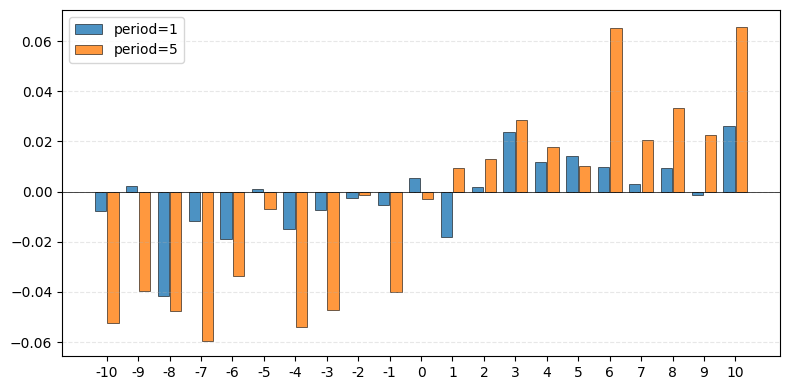

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,8650
空头(-1) 数量,7643
空仓(0) 数量,21872
多头占比,22.66%
空头占比,20.03%
空仓占比,57.31%
交易日数量,112
总收益(非年化%),1.99
总交易次数（开平算一次）,1842
日均交易次数（开平算一次）,16.45


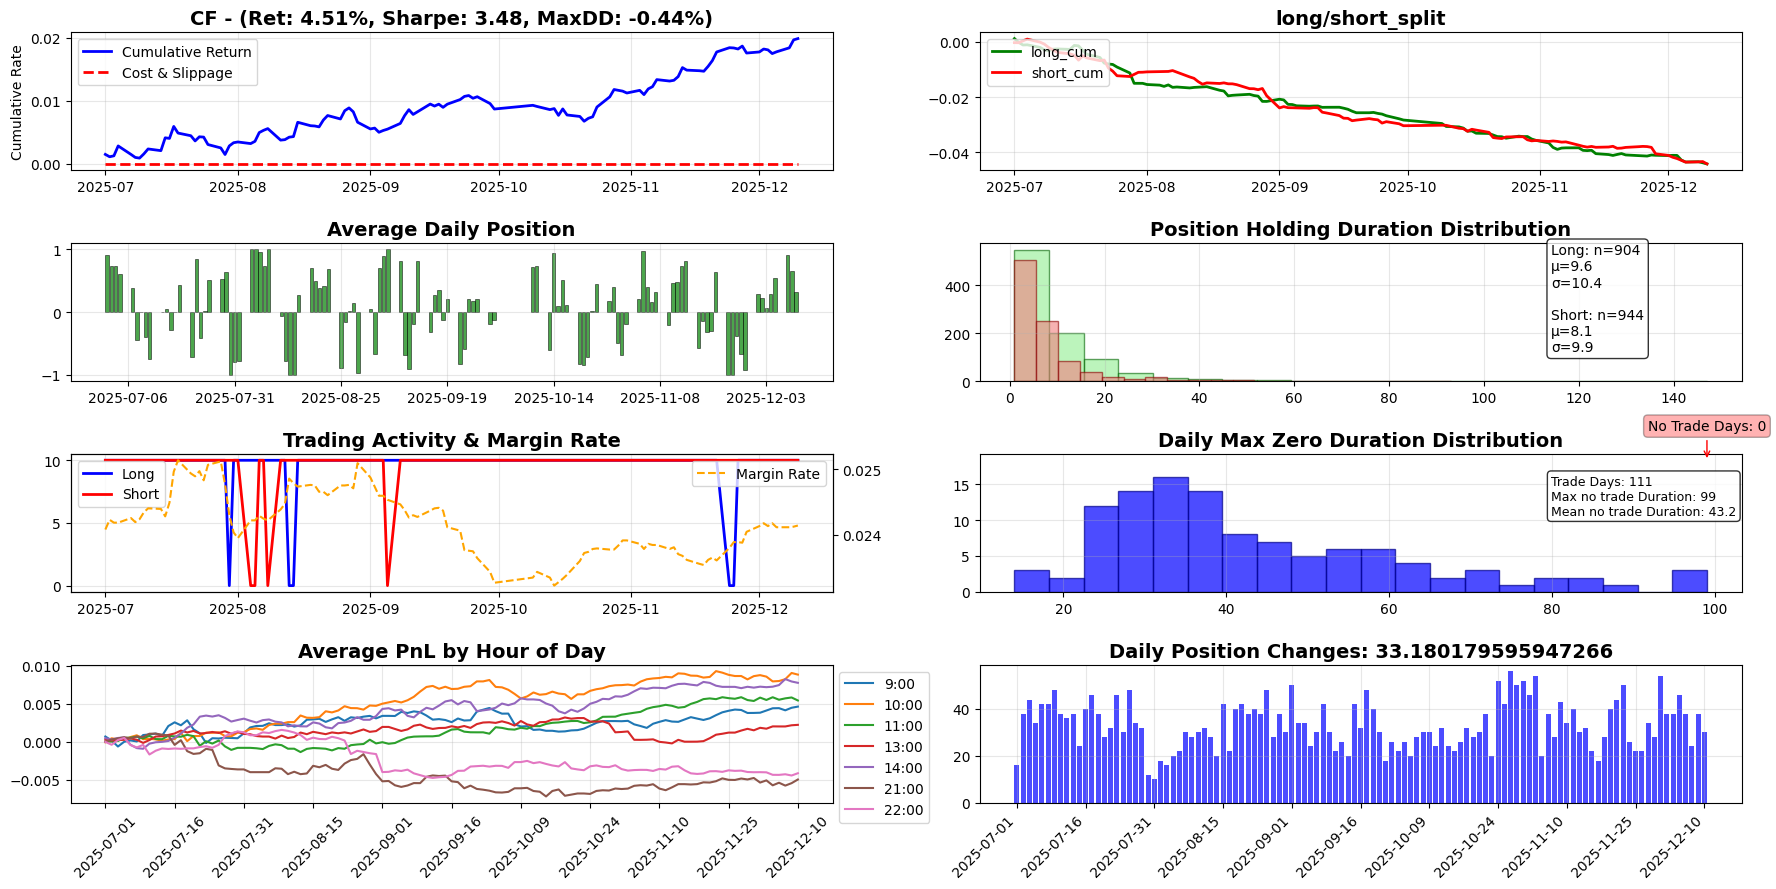

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: CF
📅 总交易日数: 111
📊 总数据点: 40293
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)